# eCoT analysis: vocab size x metric

One figure per `ent_coef` (and per training/evaluation), following `analysis-gamma.ipynb`: rows are `vocab_size`, columns are the four metrics. Per-run final performance is the mean of the last `N_TAIL_EVALS` eval points, aggregated across seeds with a normal-approximation 95% CI.

`gamma` is a single value in this CSV, so the x-axis is the compute budget instead: the fixed budgets (uniform=1..5) form a line, and the adaptive[1-5] budget is a separate black marker.

`actor` is training performance; `absolute` is the post-training re-evaluation on held-out goals (see `stoix/evaluator.py`).

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM
N_TAIL_EVALS = 3  # matches compute_final_values in analysis-gamma.ipynb

CSV_PATH = "wandb_cache_hd64-lightsout-ecot-final.csv"

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")

METRICS = (
    ("episode_discounted_return", "Disc. return"),
    ("episode_return", "Success rate"),
    ("episode_length", "Episode length"),
    ("compute_time", "Compute time"),
)
PREFIXES = (
    ("actor", f"Training (last {N_TAIL_EVALS} epochs)"),
    ("absolute", "Evaluation (heldout goals)"),
)


In [2]:
df = pd.read_csv(CSV_PATH)
df = df[(df["state"] == "finished") & ~df["sgh"]]
if df["gamma"].nunique() != 1:
    raise ValueError(f"expected a single gamma, got {sorted(df['gamma'].unique())}")

ent_coefs = sorted(df["ent_coef"].unique())
print(f"arch={df['arch'].unique()}, gamma={df['gamma'].unique()}, ent_coefs={ent_coefs}")

arch=['Transformer-ExplicitCoT'], gamma=[0.999], ent_coefs=[0.01]


In [3]:
def compute_final_values(sub, metric, n_tail=N_TAIL_EVALS):
    """Per-run final performance: mean of the last n_tail eval points."""
    tail = sub.sort_values("eval_idx").groupby("run_id").tail(n_tail)
    return (
        tail.groupby("run_id")
        .agg(
            value=(metric, "mean"),
            min_steps=("min_steps", "first"),
            max_steps=("max_steps", "first"),
            vocab_size=("vocab_size", "first"),
        )
        .dropna(subset=["value"])
        .reset_index()
    )


def budget_stats(sub, metric):
    """DataFrame[min_steps, max_steps, mean, ci, n], one row per budget present in `sub`."""
    final = compute_final_values(sub, metric)
    rows = []
    for (mn, mx), g in final.groupby(["min_steps", "max_steps"]):
        n = len(g)
        ci = CI95_Z * g["value"].std() / np.sqrt(n) if n > 1 else 0.0
        rows.append({"min_steps": mn, "max_steps": mx, "mean": g["value"].mean(), "ci": ci, "n": n})
    return pd.DataFrame(rows)


def budget_label(min_steps, max_steps):
    return f"uniform={min_steps}" if min_steps == max_steps else f"adaptive[{min_steps}-{max_steps}]"


def vocab_curves(sub, metric):
    """{budget_label: DataFrame[vocab_size, mean, ci, n]} for one metric, across every budget in `sub`."""
    final = compute_final_values(sub, metric)
    budgets = sorted(
        final[["min_steps", "max_steps"]].drop_duplicates().itertuples(index=False, name=None),
        key=lambda mm: (mm[0] != mm[1], mm[0], mm[1]),
    )
    curves = {}
    for mn, mx in budgets:
        g = final[(final["min_steps"] == mn) & (final["max_steps"] == mx)]
        # With a budget of 1 there is no thinking, so the vocab is never used: pool every vocab size
        # into one group and report the same aggregate at each vocab size.
        pooled = mn == mx == 1
        groups = [(vocab, g) for vocab in sorted(g["vocab_size"].unique())] if pooled else list(g.groupby("vocab_size"))
        rows = []
        for vocab, gg in groups:
            n = len(gg)
            ci = CI95_Z * gg["value"].std() / np.sqrt(n) if n > 1 else 0.0
            rows.append({"vocab_size": vocab, "mean": gg["value"].mean(), "ci": ci, "n": n})
        curves[budget_label(mn, mx)] = pd.DataFrame(rows).sort_values("vocab_size")
    return curves

In [4]:
def plot_grid(ent_coef, prefix, prefix_title, out_path):
    sub_ent = df[df["ent_coef"] == ent_coef]
    vocab_sizes = sorted(sub_ent["vocab_size"].unique())
    uniform_budgets = sorted(sub_ent.loc[sub_ent["min_steps"] == sub_ent["max_steps"], "min_steps"].unique())
    adaptive = sub_ent[sub_ent["min_steps"] != sub_ent["max_steps"]][["min_steps", "max_steps"]].drop_duplicates()
    # One shared x layout: uniform budgets in order, then the (single) adaptive budget.
    labels = [str(b) for b in uniform_budgets] + [
        f"var.\n[{mn}-{mx}]" for mn, mx in adaptive.itertuples(index=False)
    ]
    color_uniform = sns.color_palette("colorblind")[0]
    color_adaptive = (0.0, 0.0, 0.0)

    nrows, ncols = len(vocab_sizes), len(METRICS)
    figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=True)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey="col",
        squeeze=False,
    )
    for row_i, vocab in enumerate(vocab_sizes):
        sub = sub_ent[sub_ent["vocab_size"] == vocab]
        for col_i, (metric, metric_name) in enumerate(METRICS):
            ax = axes[row_i, col_i]
            stats = budget_stats(sub, f"{prefix}/{metric}/mean")

            uni = stats[stats["min_steps"] == stats["max_steps"]].sort_values("min_steps")
            xs = [uniform_budgets.index(b) for b in uni["min_steps"]]
            ax.plot(xs, uni["mean"], marker="x", color=color_uniform, ms=3, linewidth=1, alpha=0.9)
            ax.fill_between(xs, uni["mean"] - uni["ci"], uni["mean"] + uni["ci"], color=color_uniform, alpha=0.1)

            ada = stats[stats["min_steps"] != stats["max_steps"]]
            if not ada.empty:
                ax.errorbar(
                    [len(uniform_budgets)] * len(ada), ada["mean"], yerr=ada["ci"],
                    marker="x", color=color_adaptive, ms=3, linewidth=1, capsize=2, linestyle="none",
                )

            if "return" in metric:
                ax.set_ylim(0.0, 1.04)
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels)
            ax.grid(True, alpha=0.3)
            if row_i == 0:
                ax.set_title(metric_name)
        axes[row_i, 0].set_ylabel(f"$|V|={vocab}$")

    fig.supxlabel("Budget (thinking steps)", y=0.02)
    # fig.suptitle(f"{prefix_title}, ent\\_coef $={ent_coef:g}$")
    fig.tight_layout()
    fig.savefig(out_path, dpi=600, format="pdf", bbox_inches="tight")
    plt.show()

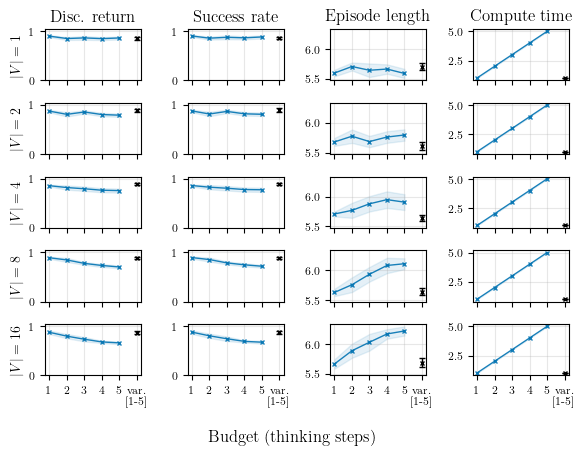

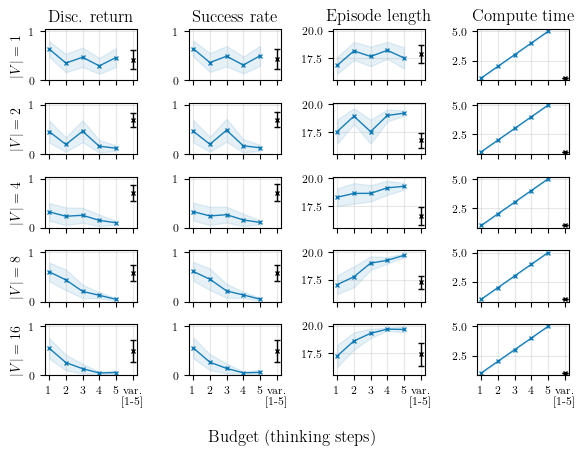

In [5]:
for ent_coef in ent_coefs:
    for prefix, prefix_title in PREFIXES:
        plot_grid(ent_coef, prefix, prefix_title, f"analysis-ecot-{prefix}-ent_coef{ent_coef:g}.pdf")

## Vocab size on the x-axis

One figure per `ent_coef`: rows are training (`actor`) / evaluation (`absolute`), columns are the four metrics, x is `vocab_size`, and each line is a budget (adaptive in black).

The uniform=1 budget never thinks, so the vocab is unused: all vocab sizes are pooled into a single aggregate, drawn as a flat dashed line.

In [8]:
def plot_vocab_grid(ent_coef, out_path):
    sub = df[df["ent_coef"] == ent_coef]
    vocab_sizes = sorted(sub["vocab_size"].unique())
    all_budget_labels = sorted(
        {budget_label(mn, mx) for mn, mx in sub[["min_steps", "max_steps"]].drop_duplicates().itertuples(index=False)},
        key=lambda b: (b.startswith("adaptive"), b),
    )
    palette = dict(zip(all_budget_labels, sns.color_palette("colorblind", n_colors=len(all_budget_labels))))
    palette["adaptive[1-5]"] = (0.0, 0.0, 0.0)

    nrows, ncols = len(PREFIXES), len(METRICS)
    figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=False)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=False,
        squeeze=False,
    )
    for row_i, (prefix, prefix_title) in enumerate(PREFIXES):
        for col_i, (metric, metric_name) in enumerate(METRICS):
            ax = axes[row_i, col_i]
            for budget, stats in vocab_curves(sub, f"{prefix}/{metric}/mean").items():
                xs = [vocab_sizes.index(v) for v in stats["vocab_size"]]
                color = palette[budget]
                pooled = budget == "uniform=1"

                label = budget
                if "uniform" in budget:
                    label = "$c = {}$".format(budget.split("=")[-1])
                elif "adaptive" in budget:
                    splits = budget.split("[")[1].split("-")
                    min_c = splits[0]
                    max_c = splits[1][:-1]
                    label = "$c \\in [{}, {}]$".format(min_c, max_c)
                ax.plot(
                    xs, stats["mean"], marker=None if pooled else "x", linestyle="--" if pooled else "-",
                    color=color, ms=3, linewidth=1, alpha=0.9,
                    label=label if row_i == 0 and col_i == 0 else "",
                )
                ax.fill_between(xs, stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], color=color, alpha=0.1)
            if "return" in metric:
                ax.set_ylim(0.0, 1.04)
            ax.set_xticks(range(len(vocab_sizes)))
            ax.set_xticklabels([str(v) for v in vocab_sizes])
            ax.grid(True, alpha=0.3)
            if row_i == 0:
                ax.set_title(metric_name)
        axes[row_i, 0].set_ylabel(prefix_title.replace(" (", "\n("))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.supxlabel("Vocab size $| \\mathcal{V} |$", y=0.08)
    fig.legend(handles, labels, 
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=6,
        borderaxespad=0.0,
        frameon=True,
    )
    # fig.suptitle(f"ent\\_coef $={ent_coef:g}$", y=1.12)
    fig.tight_layout()
    fig.savefig(out_path, dpi=600, format="pdf", bbox_inches="tight")
    plt.show()

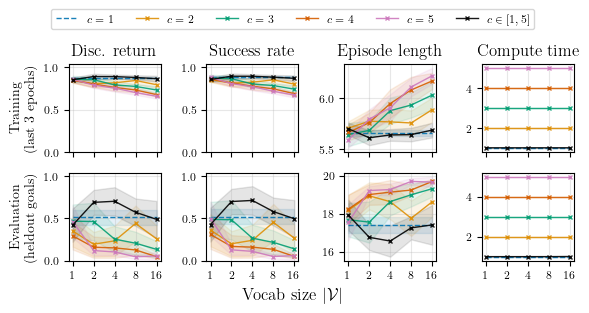

In [9]:
for ent_coef in ent_coefs:
    plot_vocab_grid(ent_coef, f"analysis-ecot-vocab-ent_coef{ent_coef:g}.pdf")